### Importing necessary libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
%matplotlib inline

In [2]:
# Reading the dataset from a CSV file
df = pd.read_csv('titanic.csv')
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


### Data Pre-processing

In [3]:
# Displaying the first 5 rows of the dataset
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
# Displaying the last 5 rows of the dataset
df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [5]:
# Checking the number of rows and columns in the dataset
df.shape

(891, 12)

In [6]:
# General info about the dataset including non-null counts and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


- Gives summary of all columns, their data types (int, float, object), and how many non-null (not-missing) values each has.

In [7]:
# Getting summary statistics for numerical columns
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


- Gives basic statistical summaries (mean, median, min, max, std) for numeric columns.

In [8]:
# Checking which values are missing (True for missing)
df.isnull()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,False,False,False,False,False,False,False,False,False,False,True,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,True,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
886,False,False,False,False,False,False,False,False,False,False,True,False
887,False,False,False,False,False,False,False,False,False,False,False,False
888,False,False,False,False,False,True,False,False,False,False,True,False
889,False,False,False,False,False,False,False,False,False,False,False,False


- Shows whether each cell in the dataset is True (missing) or False (not missing).



In [9]:
# Checking total missing values in each column
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


- It counts how many missing values are in each column.

In [10]:
# Checking how many unique values each column has
df.nunique()

,0
PassengerId,891
Survived,2
Pclass,3
Name,891
Sex,2
Age,88
SibSp,7
Parch,7
Ticket,681
Fare,248


### Handle Missing Null Values

In [11]:
# Again, checking for missing values
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [12]:
# Checking how skewed the 'Age' distribution is
df["Age"].skew()

np.float64(0.38910778230082704)

In [13]:
#Fill missing Age values with the median
df['Age'].fillna(df['Age'].median(), inplace=True)

<ipython-input-13-39750ec14fcf>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)


In [14]:
#Fill missing Embarked values with the most frequent value (mode)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

<ipython-input-14-4a9c829ffa52>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)


In [15]:
#Drop 'Cabin' column due to too many missing values
df.drop(columns=['Cabin'], inplace=True)

In [16]:
#Drop columns not needed for EDA
df.drop(columns=['Name', 'Ticket'], inplace=True)

In [17]:
# Final check on missing values
print(df.isnull().sum())

PassengerId    0
Survived       0
Pclass         0
Sex            0
Age            0
SibSp          0
Parch          0
Fare           0
Embarked       0
dtype: int64


In [18]:
# Checking how many survived vs not survived
df.value_counts()

,,,,,,,,,count
PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,
891,0,3,male,32.0,0,0,7.7500,Q,1
1,0,3,male,22.0,1,0,7.2500,S,1
2,1,1,female,38.0,1,0,71.2833,C,1
3,1,3,female,26.0,0,0,7.9250,S,1
4,1,1,female,35.0,1,0,53.1000,S,1
...,...,...,...,...,...,...,...,...,...
16,1,2,female,55.0,0,0,16.0000,S,1
15,0,3,female,14.0,0,0,7.8542,S,1
14,0,3,male,39.0,1,5,31.2750,S,1


### EDA: Exploratory Data Analysis

#### Univariate Analysis

##### Categorical Variables

Text(0.5, 1.0, 'Survival Count')

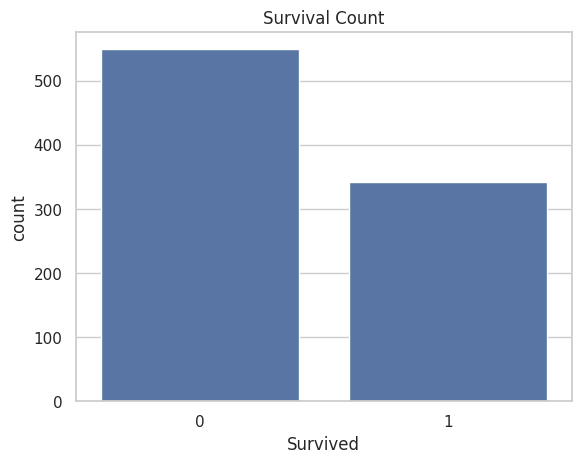

In [19]:
# Visualizing the count of passengers by survival status
sns.countplot(x='Survived', data=df)
plt.title("Survival Count")

- It shows that a larger number of passengers did not survive compared to those who did.

Text(0.5, 1.0, 'Gender Distribution')

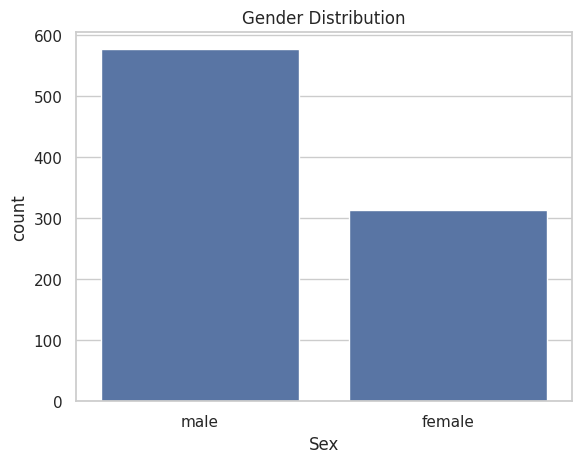

In [22]:
sns.countplot(x='Sex', data=df)
plt.title("Gender Distribution")

- The bar plot above shows the gender distribution of passengers on the Titanic. There were more male passengers than female passengers on board.

Text(0.5, 1.0, 'Passenger Class Distribution')

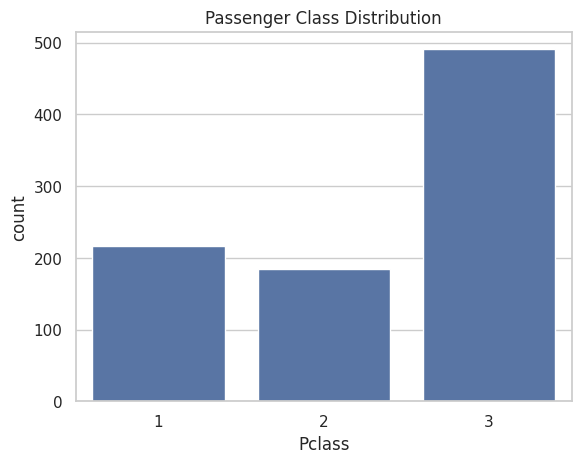

In [23]:
sns.countplot(x='Pclass', data=df)
plt.title("Passenger Class Distribution")

- The bar plot above shows the number of passengers in each ticket class (Pclass) on the Titanic. Class 3 had the highest number of passengers. Class 1 and Class 2 had significantly fewer passengers compared to Class 3.



##### Numerical Variables

Text(0.5, 1.0, 'Age Distribution')

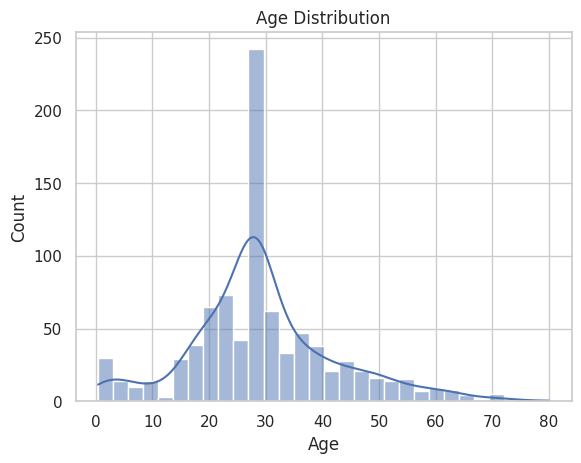

In [ ]:
# Plotting the distribution of Age using histogram
sns.histplot(df['Age'], bins=30, kde=True)
plt.title("Age Distribution")

- This histogram displays the age distribution of Titanic passengers.

Text(0.5, 1.0, 'Fare Distribution')

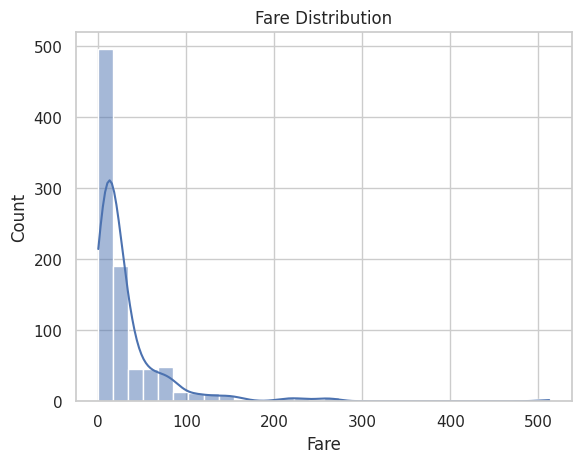

In [ ]:
# Plotting the distribution of Fare using histogram
sns.histplot(df['Fare'], bins=30, kde=True)
plt.title("Fare Distribution")

- This histogram shows how fare prices were distributed among Titanic passengers

#### Bivariate Analysis

Text(0.5, 1.0, 'Survival by Gender')

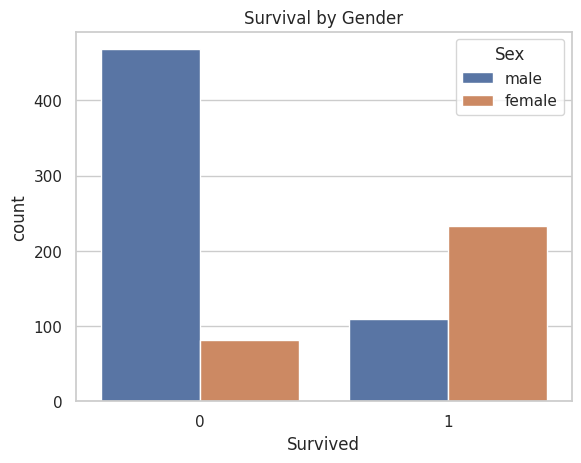

In [ ]:
# Survival Rate by Gender
sns.countplot(x='Survived', hue='Sex', data=df)
plt.title("Survival by Gender")

- This bar plot shows the survival distribution of Titanic passengers based on gender. A higher number of females survived compared to males. Conversely, more males did not survive. This pattern reflects the "women and children first" evacuation protocol followed during the disaster.



Text(0.5, 1.0, 'Survival by Passenger Class')

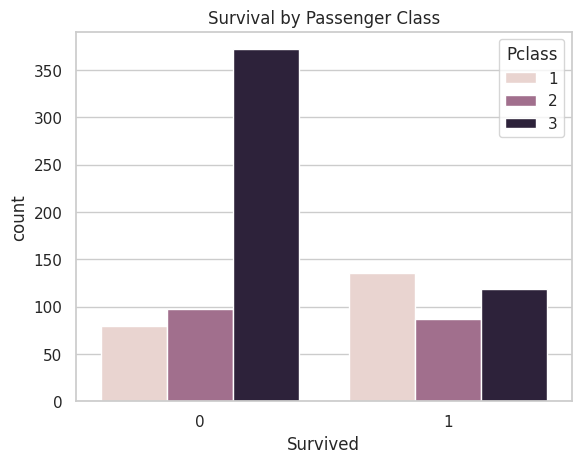

In [ ]:
# Survival Rate by Class
sns.countplot(x='Survived', hue='Pclass', data=df)
plt.title("Survival by Passenger Class")

- The graph shows survival counts by passenger class on the Titanic. It reveals that 1st class passengers had a higher survival rate, while most 3rd class passengers did not survive. This indicates that higher-class passengers had better chances of survival.

Text(0.5, 1.0, 'Age Distribution by Survival')

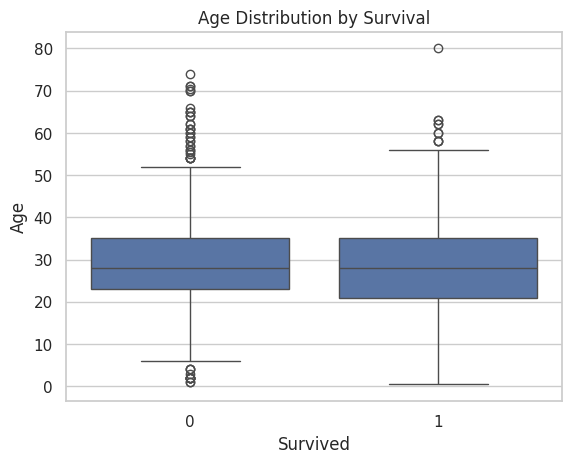

In [ ]:
# Age vs Survival (Boxplot)
sns.boxplot(x='Survived', y='Age', data=df)
plt.title("Age Distribution by Survival")

- This boxplot shows the age distribution of passengers based on whether they survived (1) or not (0). Both groups have a similar median age, but those who survived include a slightly wider age range of younger individuals. Outliers (dots) represent passengers who were much older or younger than the typical age range. This helps us see if age had any noticeable effect on survival chances.

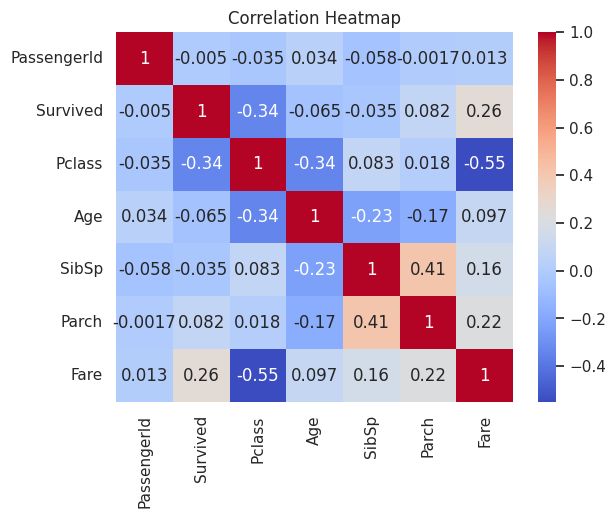

In [ ]:
# Select only numeric columns from the DataFrame
numeric_df = df.select_dtypes(include=[np.number])

# Create the heatmap for correlation analysis
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

- The heatmap shows that passengers in higher classes and those who paid higher fares were more likely to survive. Family-related features also show some correlation with survival.

In [ ]:
#Drop columns not needed for EDA
df.drop(columns=['PassengerId'], inplace=True)

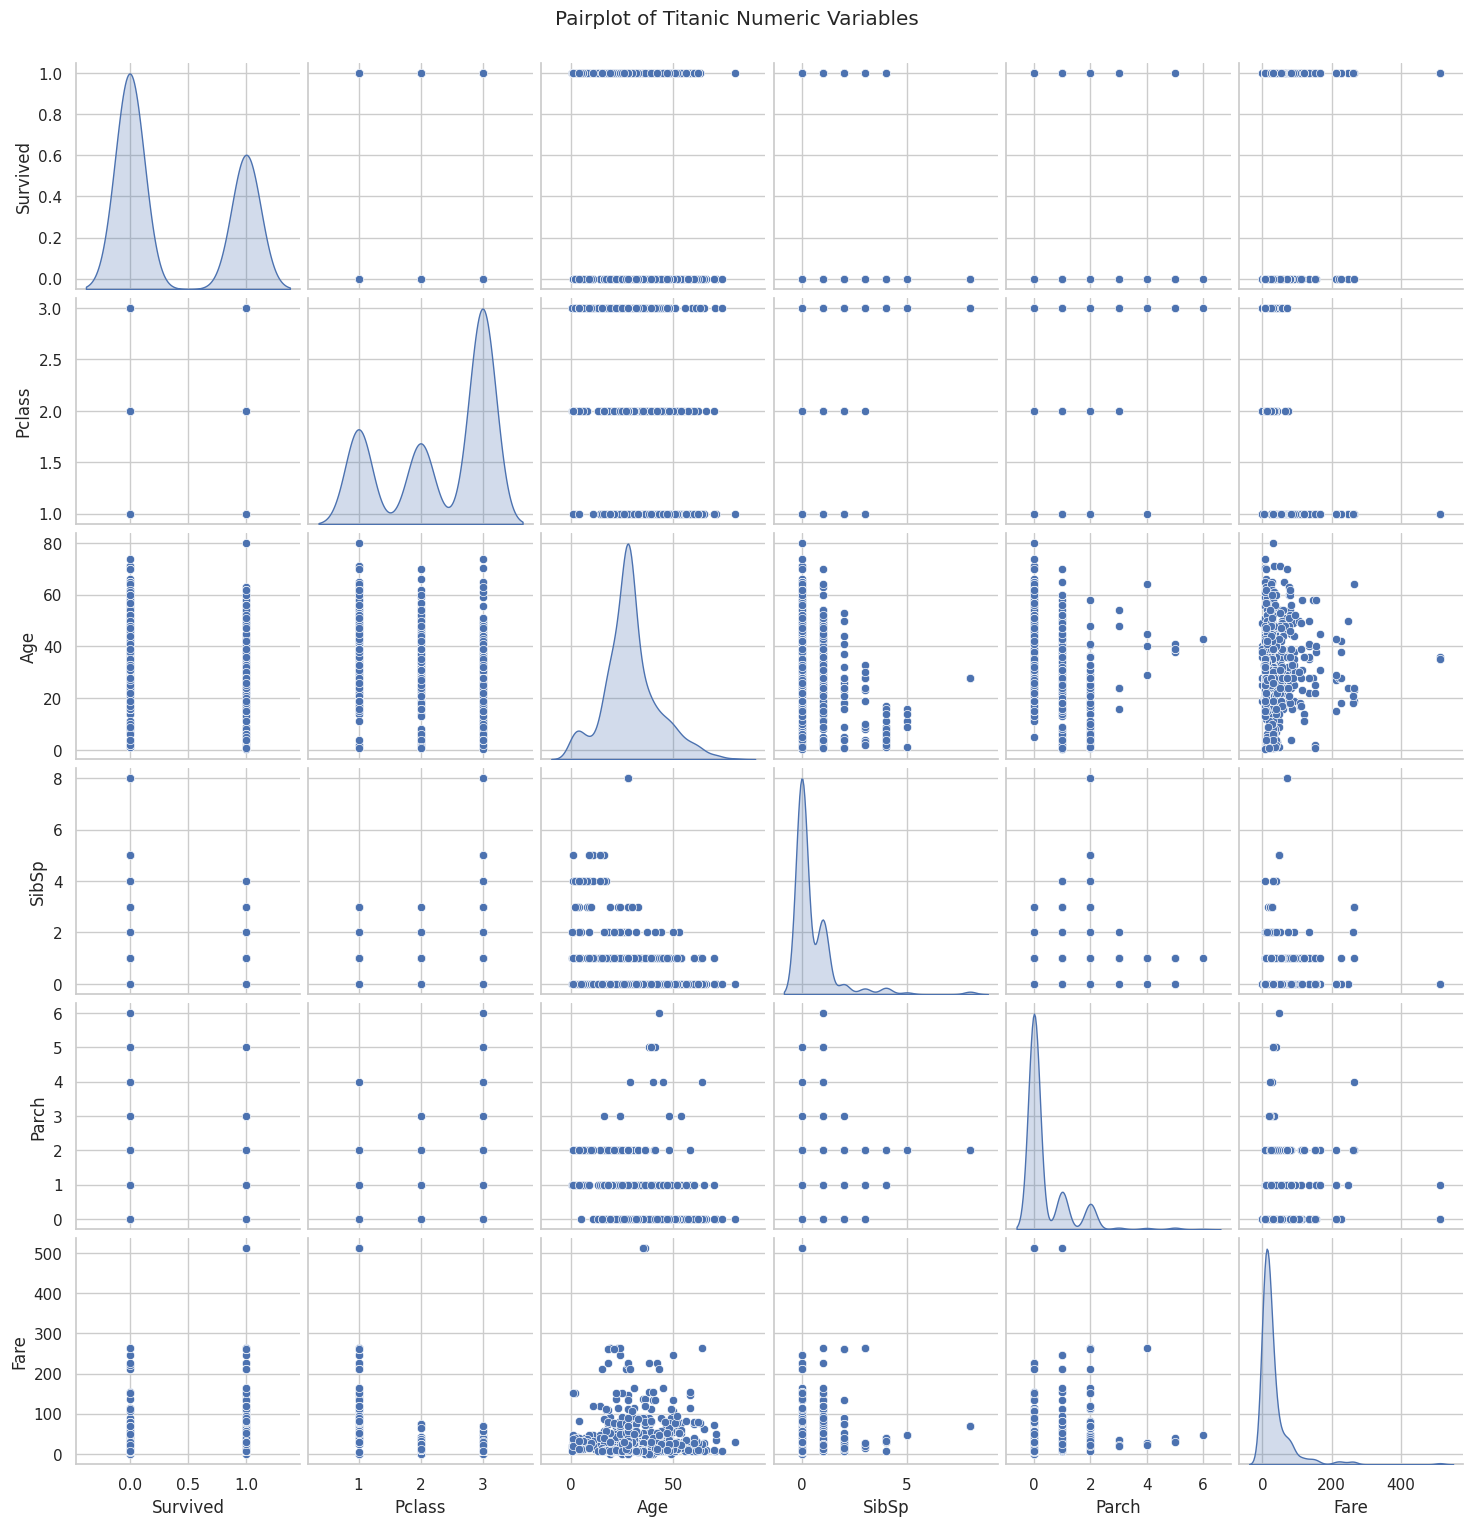

In [ ]:
# Select numeric columns that are of interest
numeric_cols = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']

# Create a pairplot
sns.pairplot(df[numeric_cols], diag_kind='kde')
plt.suptitle("Pairplot of Titanic Numeric Variables", y=1.02)
plt.show()

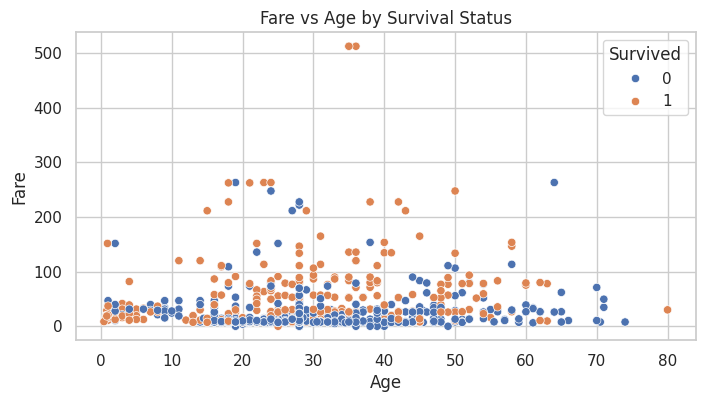

In [ ]:
# Scatterplot between Fare and Age
plt.figure(figsize=(8, 4))
sns.scatterplot(x='Age', y='Fare', hue='Survived', data=df)
plt.title("Fare vs Age by Survival Status")
plt.xlabel("Age")
plt.ylabel("Fare")
plt.legend(title="Survived")
plt.show()

- This scatter plot shows the relationship between Age and Fare, colored by Survival status. We can see that passengers who paid higher fares (especially above 100) were more likely to survive (orange dots). Most passengers, regardless of age, paid lower fares, but survivors tend to cluster more in the higher fare range, especially among younger passengers.



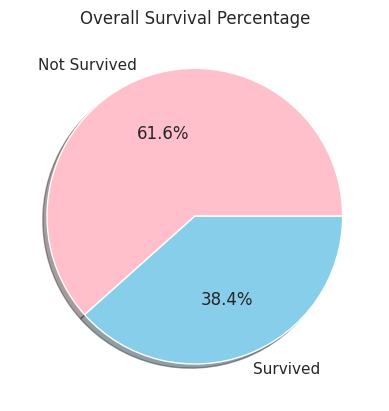

In [ ]:
df["Survived"].value_counts().plot.pie(autopct="%1.1f%%", labels=["Not Survived", "Survived"], colors=["pink", "skyblue"],shadow=True)
plt.title("Overall Survival Percentage")
plt.ylabel("")  # Remove y-label for aesthetics
plt.show()

- This pie chart shows the overall survival percentage of passengers. About 38.4% survived (sky blue), while 61.6% did not survive (pink), indicating that a majority of the passengers did not make it.

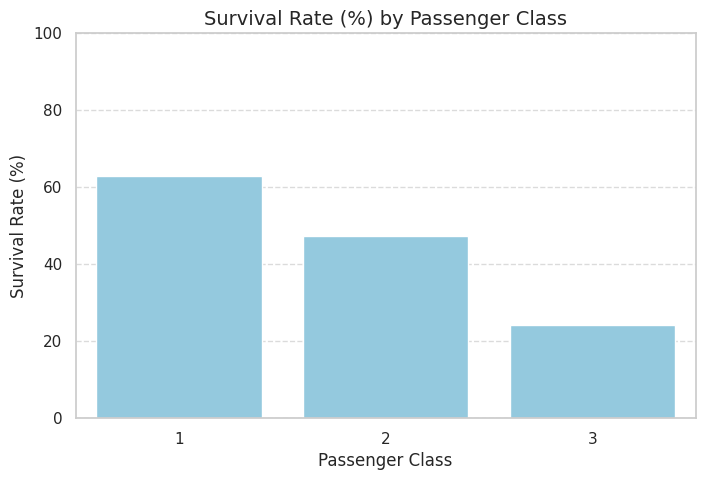

In [ ]:
# Group by 'Pclass' and calculate survival rate
survival_rate_by_class = df.groupby('Pclass')['Survived'].mean() * 100

# Reset index for plotting
survival_rate_by_class = survival_rate_by_class.reset_index()
survival_rate_by_class.columns = ['Passenger Class', 'Survival Rate (%)']

# Plot the barplot (no hue)
plt.figure(figsize=(8, 5))
sns.barplot(x='Passenger Class', y='Survival Rate (%)', data=survival_rate_by_class, color='skyblue')

# Titles and labels
plt.title("Survival Rate (%) by Passenger Class", fontsize=14)
plt.ylabel("Survival Rate (%)")
plt.xlabel("Passenger Class")
plt.ylim(0, 100)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

- This bar chart shows survival rates by passenger class. First-class passengers had the highest survival rate (over 60%), followed by second class, while third-class passengers had the lowest survival rate (around 25%). This highlights a clear link between passenger class and chances of survival.



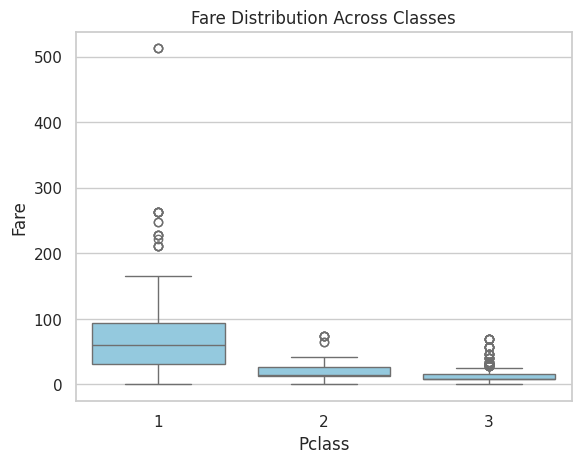

In [ ]:
# Box Plot: Fare Distribution Across Passenger Classes
sns.boxplot(x="Pclass", y="Fare", data=df, color='skyblue')
plt.title("Fare Distribution Across Classes")
plt.show()

- Passengers in higher classes paid a lot more for their tickets. The price difference between 3rd class and 1st class is quite big, showing that there was a clear gap between rich and poor passengers on the ship.









